## Introduction and Problem Statement
## Objective 
To build a Linear Regression model that predicts medical insurance charges based on personal attributes such as age, BMI, smoking status, and number of children.

## Problem Statement
Insurance companies need accurate estimates of medical expenses to manage risk and pricing. This project aims to predict insurance charges using customer demographic and health-related information.

## Dataset Understanding and Description
## Features 
| Feature  | Description                      |
| -------- | -------------------------------- |
| age      | Age of beneficiary               |
| sex      | Gender                           |
| bmi      | Body Mass Index                  |
| children | Number of dependents             |
| smoker   | Smoking status                   |
| region   | Residential region               |
| charges  | Insurance cost (Target Variable) |

## Load Dataset

In [28]:
# Import libraries 
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [29]:
# Load insurance dataset
insurance = pd.read_csv(r"C:\Users\UDDYBON\Downloads\insurance.csv")

In [30]:
# Display first five rows 
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Data Cleaning and Preparation

In [31]:
# View dataset information
insurance.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [32]:
# Check for missing values
insurance.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [33]:
# Check duplicate rows 
insurance.duplicated().sum()

np.int64(1)

In [34]:
# Convert categorical variables into numerical variables 
insurance = pd.get_dummies(insurance, 
                           columns=["sex","smoker","region"],
                           drop_first=True)

## Exploratory Data Analysis (EDA)

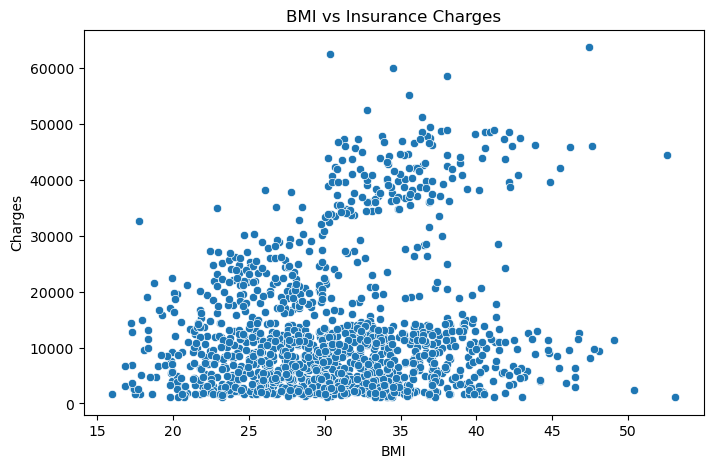

In [35]:
# BMI and Insurance charges relationship
plt.figure(figsize=(8,5))

sns.scatterplot(data=insurance,
                x="bmi",
                y="charges")

plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

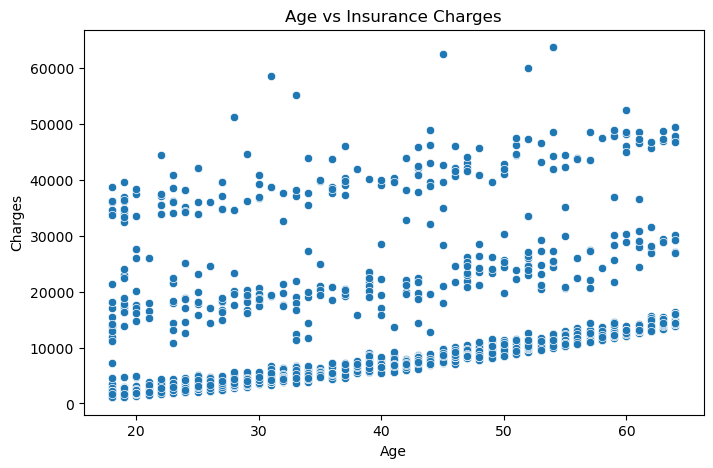

In [36]:
# Age and insurance charges relationship
plt.figure(figsize=(8,5))

sns.scatterplot(data=insurance,
                x="age",
                y="charges")

plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

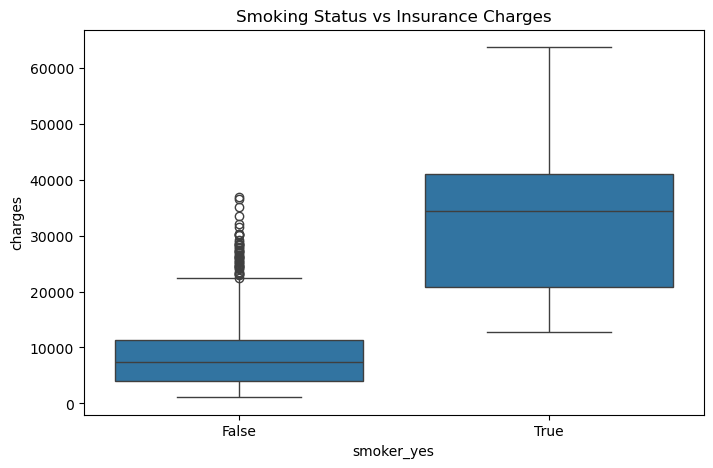

In [37]:
# Smoking status compared with insurance charges 
plt.figure(figsize=(8,5))

sns.boxplot(data=insurance,
            x="smoker_yes",
            y="charges")

plt.title("Smoking Status vs Insurance Charges")
plt.show()

## Model Training and Testing

In [38]:
# Independent variables 
X = insurance.drop("charges",
                   axis=1)

In [39]:
# Target variable 
y = insurance["charges"]

In [40]:
# Split into training and testing sets 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    random_state=42)

## Linear Regression Model

In [41]:
# Import model
from sklearn.linear_model import LinearRegression

In [42]:
# Create model 
model = LinearRegression()

In [43]:
# Train model 
model.fit(X_train,
          y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Predictions

In [44]:
# Predict inusurance charges
predictions = model.predict(X_test)

## Actual vs Predicted Plot

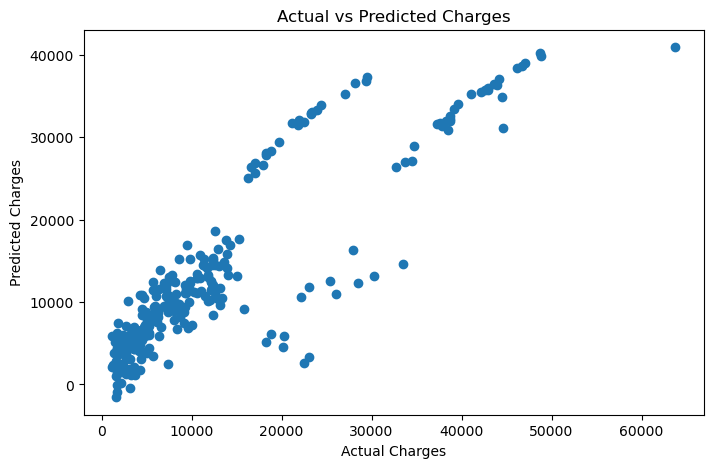

In [45]:
# Compare actual and predicted values 
plt.figure(figsize=(8,5))

plt.scatter(y_test, 
            predictions)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")

plt.show()

## Evaluation Metrics

In [46]:
# Mean Absolute Error (MAE)
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, 
                          predictions)

print("MAE:", mae)

MAE: 4181.1944737536505


In [47]:
# Root Mean Squared Error (RMSE)
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, 
                                  predictions))

print("RMSE:", rmse)

RMSE: 5796.2846592762735


## Conclusion and Key Insights 
## Conclusion
A Linear Regression model was successfully developed to predict insurance charges. Exploratory analysis demonstrated that age, BMI, and smoking status all influence insurance costs, with smoking showing the strongest impact.

## Key Insights
1) BMI vs Insurance Charges

From the scatter plot:
* There is a positive relationship between BMI and insurance charges.
* As BMI increases, insurance costs generally increase.
* The relationship is not perfectly linear, indicating that other factors also influence charges.

Observation
* Several high-cost outliers are visible among individuals with higher BMI values.

2) Age vs Insurance Charges

From the scatter plot:
* Insurance charges generally increase with age.
* Older individuals tend to incur higher medical expenses than younger individuals.

Observation
* Multiple charge bands are visible, suggesting interactions with other variables such as smoking status.

3) Smoking Status vs Insurance Charges

From the boxplot:
* Smoking status has the strongest visible impact on insurance charges.
* Smokers exhibit substantially higher median insurance costs than non-smokers.
* Smokers also show greater variability in charges.

Observation
* Smoking appears to be one of the most important determinants of insurance expenses.

4) Model Performance

From the Actual vs Predicted plot:
* Predicted values closely follow actual values.
* Most points cluster around the diagonal line, indicating good predictive performance.
* Some deviations exist for extremely high charges.

5) Evaluation Metrics

Based on the MAE and RMSE calculations:
* The model provides reasonably accurate estimates of insurance costs.
* RMSE being larger than MAE suggests the presence of some larger prediction errors.

## Overall Business Insight
Age, BMI, and smoking behavior significantly affect healthcare costs. Also, smoking cessation programs could potentially reduce healthcare expenditures.